In [1]:
import pandas as pd

# Load Plant 1's generation data
gen_data = pd.read_csv('../data/Plant_1_Generation_Data.csv')

# Look at the first few rows
gen_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [2]:
# How many unique inverters (source keys) does Plant 1 have?
print("Number of inverters:", gen_data['SOURCE_KEY'].nunique())

# What's the date range?
print("First timestamp:", gen_data['DATE_TIME'].min())
print("Last timestamp:", gen_data['DATE_TIME'].max())

# Check for missing values
gen_data.isnull().sum()

Number of inverters: 22
First timestamp: 01-06-2020 00:00
Last timestamp: 31-05-2020 23:45


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [3]:
gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
gen_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[us]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  str           
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 4.7 MB


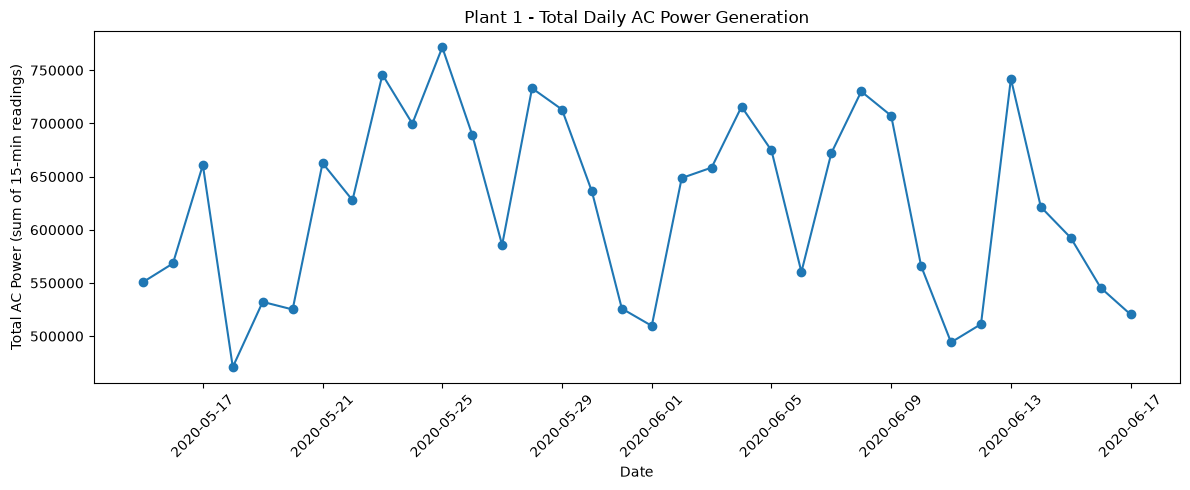

In [5]:
import matplotlib.pyplot as plt

# Add a "date only" column (without the time) so we can group by day
gen_data['DATE'] = gen_data['DATE_TIME'].dt.date

# Sum AC_POWER across all inverters, grouped by day
daily_total = gen_data.groupby('DATE')['AC_POWER'].sum()

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(daily_total.index, daily_total.values, marker='o')
plt.title('Plant 1 - Total Daily AC Power Generation')
plt.xlabel('Date')
plt.ylabel('Total AC Power (sum of 15-min readings)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
weather_data = pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')
weather_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [7]:
# Convert DATE_TIME from text to an actual datetime object
# Note: this file uses YYYY-MM-DD HH:MM:SS format (different from gen_data)
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Confirm it worked and check for missing values
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[us]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-null   str           
 3   AMBIENT_TEMPERATURE  3182 non-null   float64       
 4   MODULE_TEMPERATURE   3182 non-null   float64       
 5   IRRADIATION          3182 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 195.9 KB


In [8]:
# First, re-aggregate gen_data by DATE_TIME (summing AC_POWER across all 22 inverters)
# This collapses the 22 rows per timestamp into a single "plant total" row per timestamp
plant_total_power = gen_data.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()

# Now merge that with the weather data, matching rows by DATE_TIME
# 'inner' merge keeps only timestamps that exist in BOTH datasets
merged = pd.merge(plant_total_power, weather_data[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']], on='DATE_TIME', how='inner')

# Check it worked - should have AC_POWER, IRRADIATION, and temperature columns together
merged.head()

,DATE_TIME,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
0,2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507
1,2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668
2,2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306
3,2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852
4,2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423


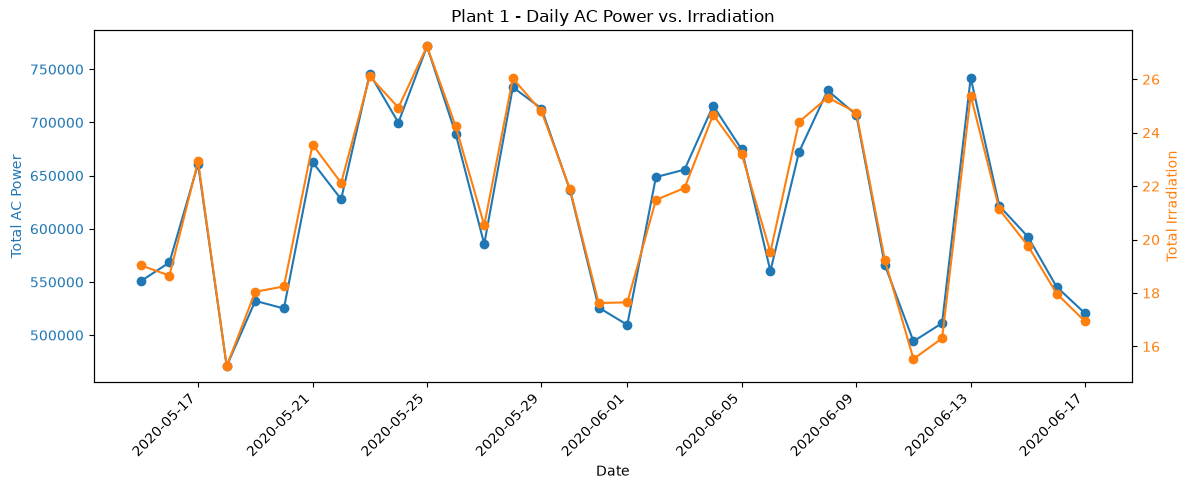

In [9]:
# Re-do the daily aggregation, but this time on the MERGED data
# so we get daily totals for both AC_POWER and IRRADIATION together
merged['DATE'] = merged['DATE_TIME'].dt.date
daily_comparison = merged.groupby('DATE')[['AC_POWER', 'IRRADIATION']].sum().reset_index()

# Create a figure with two y-axes since AC_POWER and IRRADIATION have very different scales
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot AC_POWER on the left y-axis (blue)
ax1.plot(daily_comparison['DATE'], daily_comparison['AC_POWER'], color='tab:blue', marker='o', label='AC Power')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total AC Power', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis sharing the same x-axis, for IRRADIATION (orange)
ax2 = ax1.twinx()
ax2.plot(daily_comparison['DATE'], daily_comparison['IRRADIATION'], color='tab:orange', marker='o', label='Irradiation')
ax2.set_ylabel('Total Irradiation', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Plant 1 - Daily AC Power vs. Irradiation')
fig.autofmt_xdate(rotation=45)  # rotates date labels so they don't overlap
plt.tight_layout()
plt.show()

## Finding: Irradiation drives daily generation variability

  Comparing daily AC power output to daily irradiation shows the two 
  track almost perfectly across the full 34-day period, including 
  matching dips on 2020-05-17 and 2020-06-09/10, and matching peaks 
  around 2020-05-25 and 2020-06-13.

  **Takeaway:** Plant 1's variability is weather-driven, not equipment-driven.
  No dips appear where irradiation stayed high but power dropped, which 
  would be the signature of a faulty/underperforming inverter.

In [11]:
# Group by SOURCE_KEY (each inverter) and calculate the average DC_POWER for each
# This gives us one average output value per inverter, so we can compare them side by side
inverter_avg = gen_data.groupby('SOURCE_KEY')['DC_POWER'].mean().sort_values()

# Show all 22 inverters, sorted from lowest to highest average output
inverter_avg

SOURCE_KEY
bvBOhCH3iADSZry    2828.998291
1BY6WEcLGh8j5v7    2873.720981
ih0vzX44oOqAx2f    3097.714161
7JYdWkrLSPkdwr4    3132.891955
z9Y9gH1T5YWrNuG    3134.037738
ZoEaEvLYb1n2sOq    3139.009808
sjndEbLyjtCKgGv    3148.270450
zBIq5rxdHJRwDNY    3148.590013
WRmjgnKYAwPKWDb    3155.384433
rGa61gmuvPhdLxV    3163.240929
pkci93gMrogZuBj    3166.599439
wCURE6d3bPkepu2    3170.704424
YxYtjZvoooNbGkE    3179.492570
zVJPv84UY57bAof    3187.236622
ZnxXDlPa8U1GXgE    3194.059104
uHbuxQJl8lW7ozc    3195.316080
iCRJl6heRkivqQ3    3196.074675
VHMLBKoKgIrUVDU    3210.102563
McdE0feGgRqW7Ca    3211.307245
3PZuoBAID5Wc2HD    3221.015673
1IF53ai7Xc0U56Y    3226.336768
adLQvlD726eNBSB    3269.567669
Name: DC_POWER, dtype: float64

In [12]:
# Group by SOURCE_KEY (each inverter) and calculate the average DC_POWER for each
# This gives us one average output value per inverter, so we can compare them side by side
inverter_avg = gen_data.groupby('SOURCE_KEY')['DC_POWER'].mean().sort_values()

# Show all 22 inverters, sorted from lowest to highest average output
inverter_avg

SOURCE_KEY
bvBOhCH3iADSZry    2828.998291
1BY6WEcLGh8j5v7    2873.720981
ih0vzX44oOqAx2f    3097.714161
7JYdWkrLSPkdwr4    3132.891955
z9Y9gH1T5YWrNuG    3134.037738
ZoEaEvLYb1n2sOq    3139.009808
sjndEbLyjtCKgGv    3148.270450
zBIq5rxdHJRwDNY    3148.590013
WRmjgnKYAwPKWDb    3155.384433
rGa61gmuvPhdLxV    3163.240929
pkci93gMrogZuBj    3166.599439
wCURE6d3bPkepu2    3170.704424
YxYtjZvoooNbGkE    3179.492570
zVJPv84UY57bAof    3187.236622
ZnxXDlPa8U1GXgE    3194.059104
uHbuxQJl8lW7ozc    3195.316080
iCRJl6heRkivqQ3    3196.074675
VHMLBKoKgIrUVDU    3210.102563
McdE0feGgRqW7Ca    3211.307245
3PZuoBAID5Wc2HD    3221.015673
1IF53ai7Xc0U56Y    3226.336768
adLQvlD726eNBSB    3269.567669
Name: DC_POWER, dtype: float64

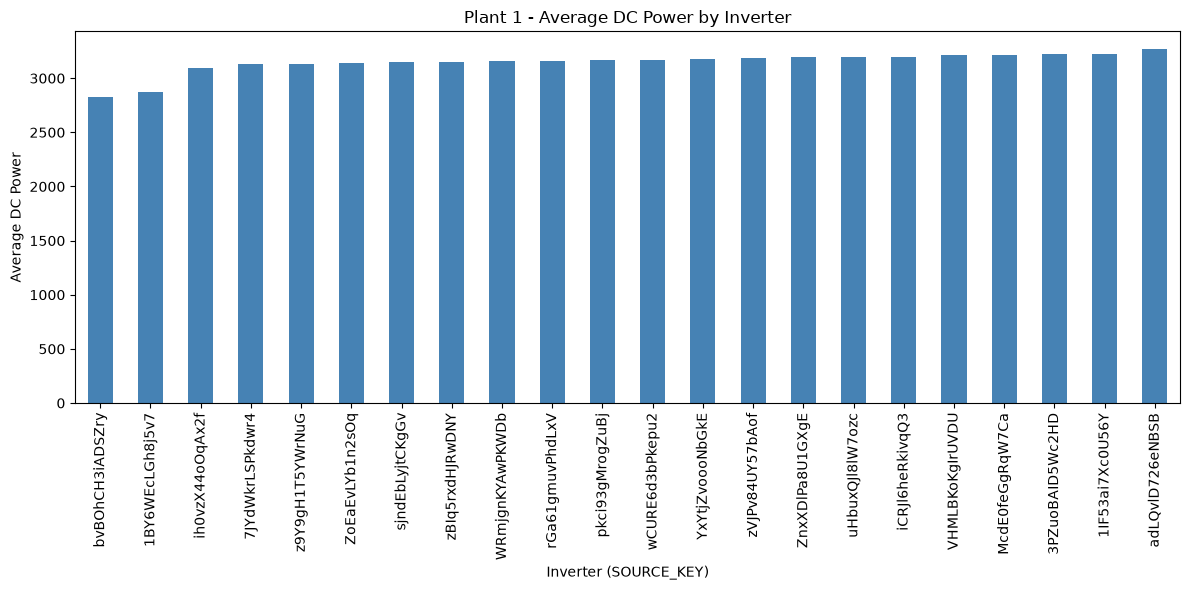

In [13]:
# Bar chart of average DC_POWER per inverter, sorted lowest to highest
# Bars make it much easier to visually spot outliers than a plain list of numbers
plt.figure(figsize=(12, 6))
inverter_avg.plot(kind='bar', color='steelblue')
plt.title('Plant 1 - Average DC Power by Inverter')
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Average DC Power')
plt.xticks(rotation=90)  # rotate labels vertically since inverter IDs are long
plt.tight_layout()
plt.show()

## Finding: Inverter-level underperformance

Average DC power output per inverter ranges from ~2,829 (lowest, 
inverter bvBOhCH3iADSZry) to ~3,270 (highest, inverter adLQvlD726eNBSB) 
— roughly a 13% gap between the lowest and highest performing inverters.

**Takeaway:** The two lowest inverters (bvBOhCH3iADSZry and 1BY6WEcLGh8j5v7) 
consistently underperform relative to the rest of the plant, which could 
indicate panel soiling, partial shading, or a wiring/connection issue 
worth flagging for inspection.

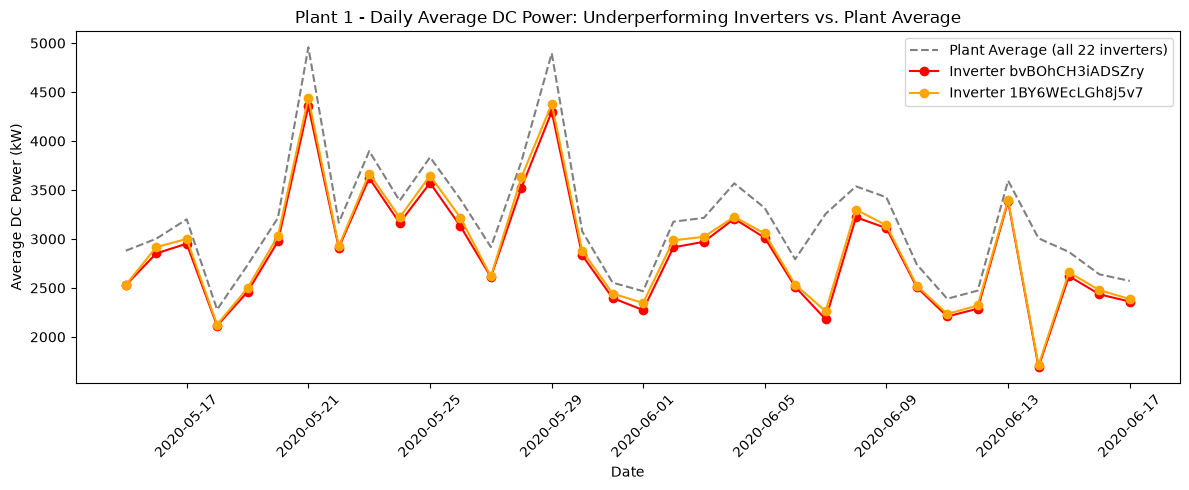

In [14]:
# Focus on the two lowest-performing inverters plus the plant average, over time
# This lets us see whether the underperformance is constant or changes across the 34 days

# Add a DATE column if not already present
gen_data['DATE'] = gen_data['DATE_TIME'].dt.date

# Filter to just the two underperforming inverters
low_1 = gen_data[gen_data['SOURCE_KEY'] == 'bvBOhCH3iADSZry']
low_2 = gen_data[gen_data['SOURCE_KEY'] == '1BY6WEcLGh8j5v7']

# Calculate each day's average DC_POWER for these two inverters
low_1_daily = low_1.groupby('DATE')['DC_POWER'].mean()
low_2_daily = low_2.groupby('DATE')['DC_POWER'].mean()

# Calculate the daily average DC_POWER across ALL inverters (plant-wide baseline)
plant_daily_avg = gen_data.groupby('DATE')['DC_POWER'].mean()

# Plot all three together
plt.figure(figsize=(12, 5))
plt.plot(plant_daily_avg.index, plant_daily_avg.values, label='Plant Average (all 22 inverters)', color='gray', linestyle='--')
plt.plot(low_1_daily.index, low_1_daily.values, label='Inverter bvBOhCH3iADSZry', color='red', marker='o')
plt.plot(low_2_daily.index, low_2_daily.values, label='Inverter 1BY6WEcLGh8j5v7', color='orange', marker='o')

plt.title('Plant 1 - Daily Average DC Power: Underperforming Inverters vs. Plant Average')
plt.xlabel('Date')
plt.ylabel('Average DC Power (kW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Finding: Underperformance is mostly consistent, but one inverter shows a distinct anomaly

Inverters bvBOhCH3iADSZry and 1BY6WEcLGh8j5v7 track the plant-wide 
average shape closely across the full 34-day period, running slightly 
below average (~10-13% lower on average) but not dramatically diverging 
day to day.

The exception is 2020-06-13, where inverter 1BY6WEcLGh8j5v7 drops to 
~1,300 kW average DC power while the plant average and the other 
flagged inverter both remain near 3,200 kW, a clear single-day anomaly 
isolated to one inverter, not explained by weather (irradiation was 
normal plant-wide that day).

**Takeaway:** The overall ~10-13% gap for these two inverters is likely 
a fixed physical cause (soiling, minor shading, slight miswiring). The 
June 13 dip for inverter 1BY6WEcLGh8j5v7 specifically looks like a 
one-off fault, worth flagging separately, e.g. a temporary disconnect, 
tripped breaker, or communication error for that day.